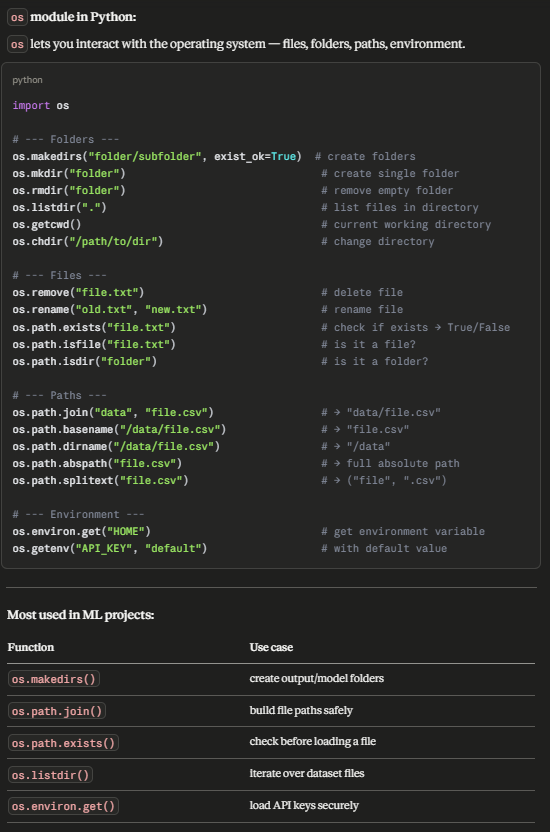

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("data/raw/005380.KS.csv")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2524 entries, 0 to 2523
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             2524 non-null   object 
 1   open             2523 non-null   float64
 2   high             2523 non-null   float64
 3   low              2523 non-null   float64
 4   close            2523 non-null   float64
 5   adjclose         2523 non-null   float64
 6   volume           2524 non-null   int64  
 7   ingested_at_utc  2524 non-null   object 
dtypes: float64(5), int64(1), object(2)
memory usage: 157.9+ KB


In [7]:
df.head(10)

,Date,open,high,low,close,adjclose,volume,ingested_at_utc
0,2016-01-04,147500.0,148000.0,143500.0,144000.0,101998.476562,445332,2026-04-23 06:31:48.394392+00:00
1,2016-01-05,143000.0,145000.0,142000.0,143500.0,101644.335938,530496,2026-04-23 06:31:48.394392+00:00
2,2016-01-06,144000.0,145000.0,139000.0,140000.0,99165.195312,769406,2026-04-23 06:31:48.394392+00:00
3,2016-01-07,138500.0,140000.0,137500.0,137500.0,97394.367188,586187,2026-04-23 06:31:48.394392+00:00
4,2016-01-08,134500.0,138000.0,133500.0,136500.0,96686.062500,888701,2026-04-23 06:31:48.394392+00:00
5,2016-01-11,134500.0,140500.0,134000.0,140000.0,99165.195312,542749,2026-04-23 06:31:48.394392+00:00
6,2016-01-12,140500.0,141500.0,139000.0,139500.0,98811.046875,386506,2026-04-23 06:31:48.394392+00:00
7,2016-01-13,140500.0,141500.0,139500.0,140500.0,99519.343750,338336,2026-04-23 06:31:48.394392+00:00
8,2016-01-14,138500.0,143500.0,136500.0,141000.0,99873.515625,664829,2026-04-23 06:31:48.394392+00:00
9,2016-01-15,141000.0,142000.0,136500.0,138500.0,98102.726562,568653,2026-04-23 06:31:48.394392+00:00


## **Data preprocessing**

### **Handling missing values**

    the column "ingested_at_utc" can be dropped due to the fact that it has no predictive features

In [8]:
df.drop("ingested_at_utc",axis=1, inplace=True)
df.dropna(inplace=True)

**Converting Date column into datatime object**

In [9]:
df["Date"] = pd.to_datetime(df["Date"])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2523 entries, 0 to 2523
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      2523 non-null   datetime64[ns]
 1   open      2523 non-null   float64       
 2   high      2523 non-null   float64       
 3   low       2523 non-null   float64       
 4   close     2523 non-null   float64       
 5   adjclose  2523 non-null   float64       
 6   volume    2523 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 157.7 KB


In [11]:
df["year"]  = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["day"]   = df["Date"].dt.day

In [12]:
df.drop("Date", axis=1, inplace = True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2523 entries, 0 to 2523
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   open      2523 non-null   float64
 1   high      2523 non-null   float64
 2   low       2523 non-null   float64
 3   close     2523 non-null   float64
 4   adjclose  2523 non-null   float64
 5   volume    2523 non-null   int64  
 6   year      2523 non-null   int32  
 7   month     2523 non-null   int32  
 8   day       2523 non-null   int32  
dtypes: float64(5), int32(3), int64(1)
memory usage: 167.5 KB


**Saving preprocessed df into new folder**

In [14]:
output_folder = "data/preprocessed"
os.makedirs(output_folder, exist_ok = True)
output_path = os.path.join(output_folder, "preprocessed_data.csv")
df.to_csv(output_path, index=False)

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2523 entries, 0 to 2523
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   open      2523 non-null   float64
 1   high      2523 non-null   float64
 2   low       2523 non-null   float64
 3   close     2523 non-null   float64
 4   adjclose  2523 non-null   float64
 5   volume    2523 non-null   int64  
 6   year      2523 non-null   int32  
 7   month     2523 non-null   int32  
 8   day       2523 non-null   int32  
dtypes: float64(5), int32(3), int64(1)
memory usage: 167.5 KB


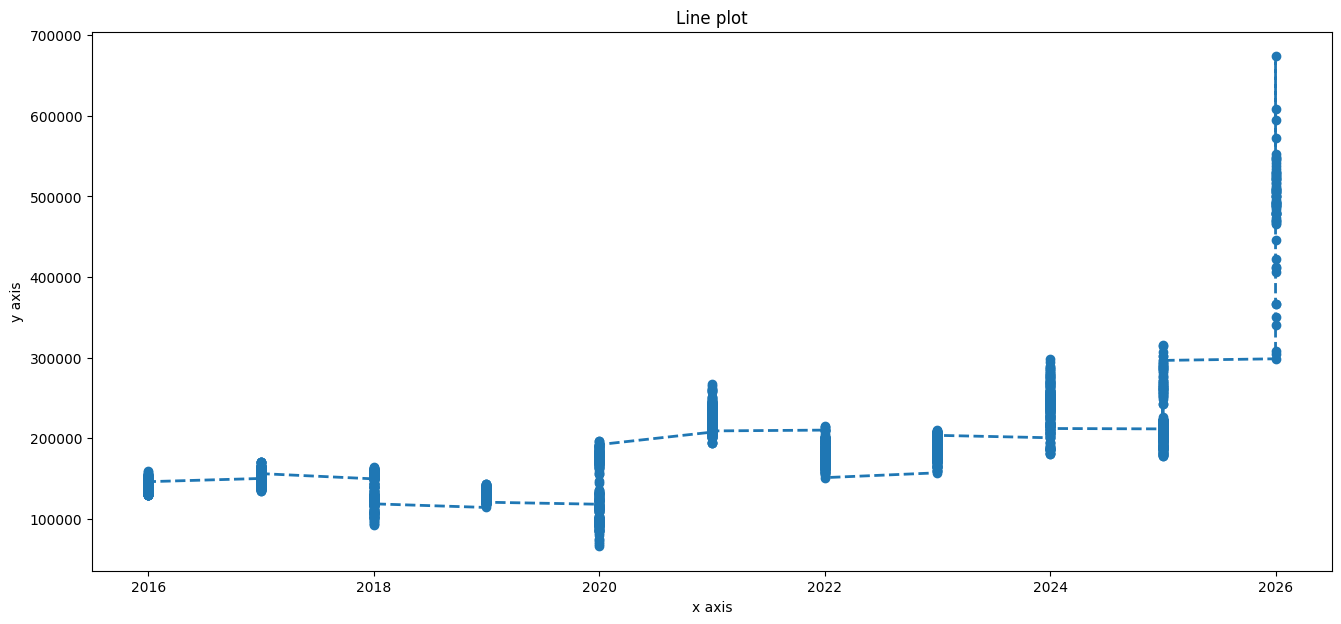

In [17]:
plt.figure(figsize=(16,7))
plt.plot(df["year"], df["close"], linewidth=2, linestyle="--", marker="o")
plt.title("Line plot")
plt.xlabel("x axis")
plt.ylabel("y axis")
plt.show()

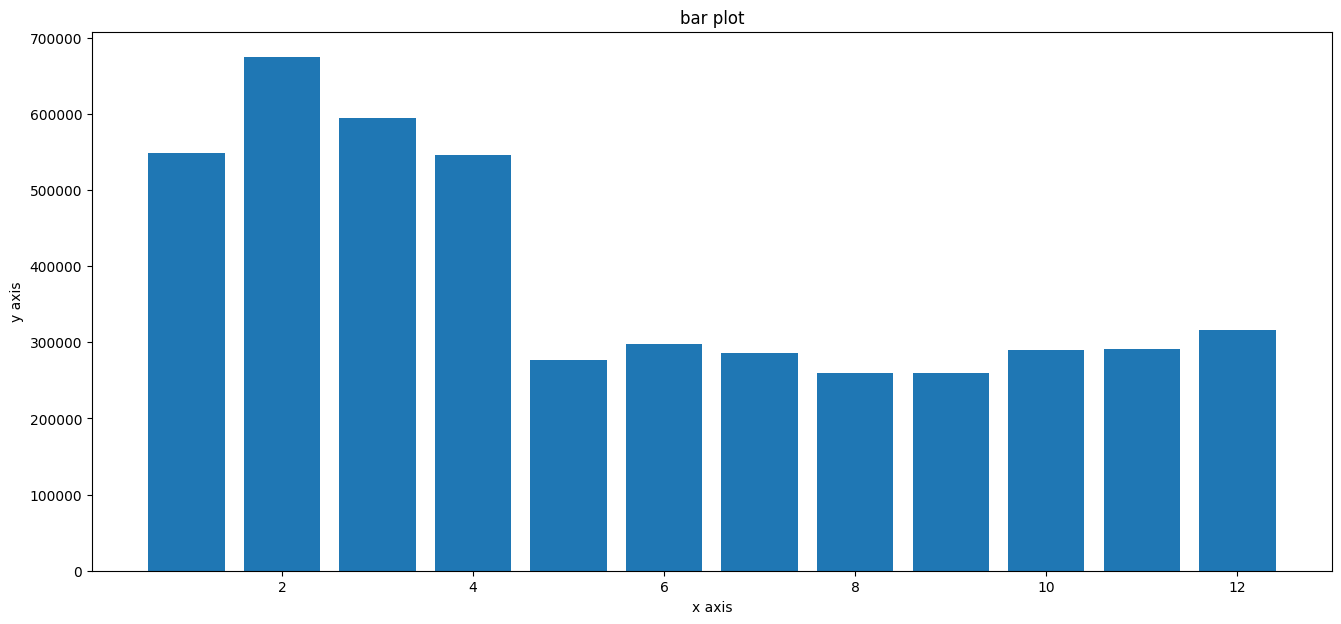

In [18]:
plt.figure(figsize=(16,7))
plt.bar(df["month"], df["close"])
plt.title("bar plot")
plt.xlabel("x axis")
plt.ylabel("y axis")
plt.show()

**Implementing decision tree regressor and random forest regressor to predict closing prices**

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2523 entries, 0 to 2523
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   open      2523 non-null   float64
 1   high      2523 non-null   float64
 2   low       2523 non-null   float64
 3   close     2523 non-null   float64
 4   adjclose  2523 non-null   float64
 5   volume    2523 non-null   int64  
 6   year      2523 non-null   int32  
 7   month     2523 non-null   int32  
 8   day       2523 non-null   int32  
dtypes: float64(5), int32(3), int64(1)
memory usage: 167.5 KB


In [20]:
x = df.drop("close", axis=1)
y = df["close"]

**Decision Tree Regressor**

In [23]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np


x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

dt = DecisionTreeRegressor()

dt.fit(x_train, y_train)

y_pred = dt.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(mae)
print(mse)
print(rmse)
print(r2)


1515.2475247524753
9841108.91089109
3137.0541772323745
0.997723664164189


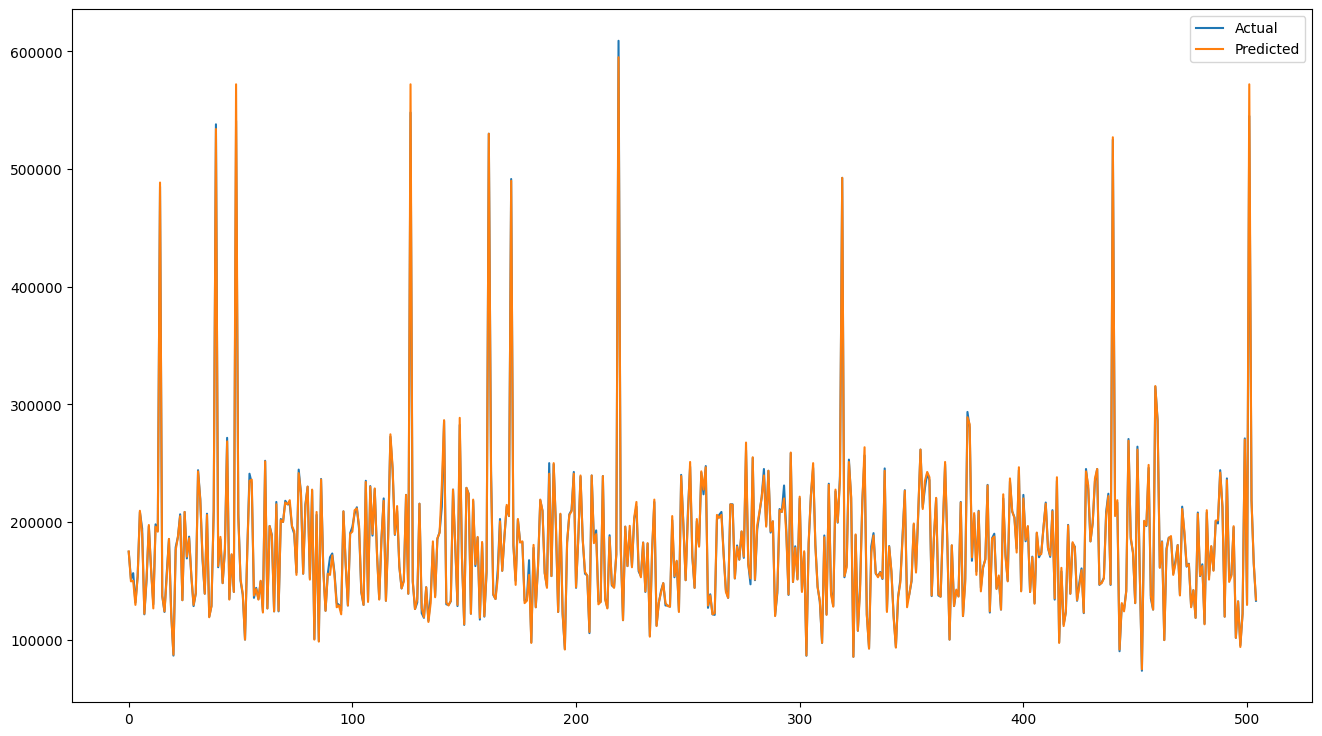

In [25]:

plt.figure(figsize=(16,9))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np


x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

rf = DecisionTreeRegressor()

rf.fit(x_train, y_train)

y_pred = rf.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(mae)
print(mse)
print(rmse)
print(r2)


1599.2079207920792
10918574.257425742
3304.3265966647036
0.9974744368664962


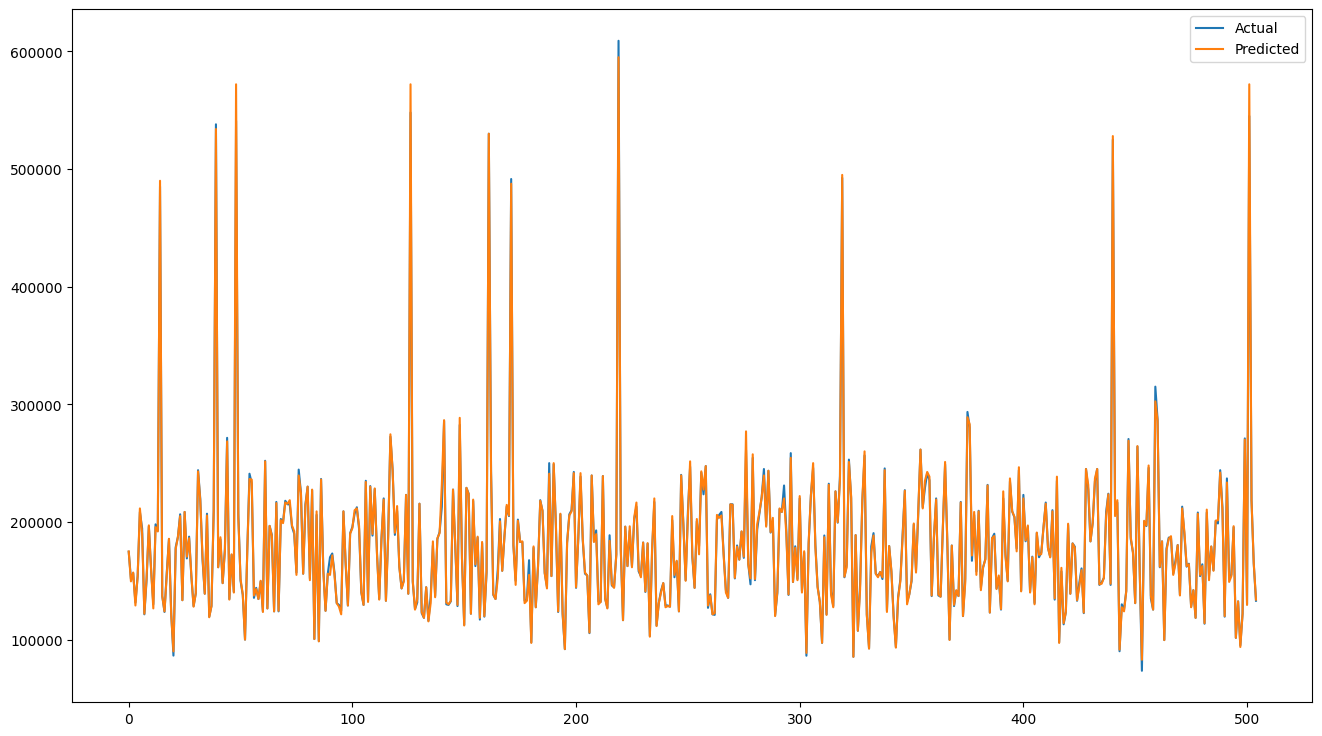

In [27]:
plt.figure(figsize=(16,9))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()